# 13_核方法-ANOVA核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，一起来聊聊核方法之ANOVA核\~

机器学习中，有时候我们用一个函数，把原来的数据“映射”到一个更高维的空间，在那里做事情（比如分类、回归）会更容易。这种“函数”就叫做**核函数（Kernel Function）**。

核方法的核心思想是：**不直接算出映射后的特征，而是通过核函数间接计算点与点之间的相似度。**

常见的核函数有：线性核、多项式核、RBF（高斯）核，**ANOVA核**就是其中一种。

### 什么是 ANOVA 核？

ANOVA 核的一个常见形式如下：


$$
K(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^d \exp\left(-\gamma (x_i - y_i)^2\right)^r
$$


- $\mathbf{x}, \mathbf{y}$：两个样本向量。
- $d$：维度（特征数）。
- $\gamma$：控制影响距离的参数（类似 RBF 核）。
- $r$：控制多项式程度的参数。

这看起来有点复杂，你可以这样理解：

- 核函数本质上是在问：两个样本“像不像”？
- ANOVA核做了一件事：**分别比较每一维度上的数值相似性，然后把它们组合起来**。

就好像我们在比较两个人是不是相似，我们可以从**身高、体重、年龄**等多个角度分别比较，然后再把这些结果加在一起得出一个总“相似度”。

这里：

- 每一项 $\exp(-\gamma (x_i - y_i)^2)^r$ 就是在第 $i$ 个特征上计算一个相似度。
- 把所有特征的结果加起来，就是最终的核值。

相比起 RBF 核（是对整体向量距离计算一个指数函数），ANOVA 核**更关注每个特征单独的作用**，适合处理那些“特征间交互不强”的问题。

### 举个例子

假设我们有两个样本：


$$
\mathbf{x} = [2, 3]
$$


$$
\mathbf{y} = [2, 4]
$$


设定参数 $\gamma = 1$，$r = 2$，我们就来计算一下 ANOVA 核：


$$
K(\mathbf{x}, \mathbf{y}) = \exp(-(2 - 2)^2)^2 + \exp(-(3 - 4)^2)^2 = \exp(0)^2 + \exp(-1)^2
$$


$$
= (1)^2 + (e^{-1})^2 = 1 + (1/e^2) \approx 1 + 0.1353 = 1.1353
$$


所以，核值为 1.1353，表示这两个样本还算比较相似。

总之，**ANOVA 核就是一种“把每个特征单独看待再综合”的相似度函数，适合特征之间互不影响的情况，比一般的核函数更细致地处理每个特征。**

## 原理详解

### 1. 核方法的基本思想

在核方法中，比如支持向量机（SVM），我们经常使用一个核函数 $K(\mathbf{x}, \mathbf{y})$，它可以被看作两个样本 $\mathbf{x}, \mathbf{y}$ 在某个高维空间中映射之后的内积：


$$
K(\mathbf{x}, \mathbf{y}) = \langle \phi(\mathbf{x}), \phi(\mathbf{y}) \rangle
$$


其中，$\phi: \mathbb{R}^d \to \mathcal{H}$ 是某种映射函数，把低维空间中的样本映射到高维（甚至无限维）特征空间 $\mathcal{H}$。

这允许我们在原始空间中非线性地学习决策边界，而不需要显式计算高维映射，只需核函数即可完成计算，称为**核技巧（kernel trick）**。

### 2. ANOVA 核的核心定义

ANOVA 核的一般定义形式如下：


$$
K(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^d \left[ \exp\left( -\gamma (x_i - y_i)^2 \right) \right]^r
$$


其中：

- $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$：输入样本向量；
- $x_i, y_i$：第 $i$ 个特征；
- $\gamma > 0$：核宽度参数，控制对特征差异的敏感度；
- $r \in \mathbb{N}$：一个整数次幂参数，用于控制非线性程度。

这个定义本质上是将**每一个特征维度上的 RBF 核分别计算出来**，再经过 $r$ 次幂之后加总。

### 3. 为何叫 ANOVA ？

“ANOVA”这个名字来自于统计学中**方差分析（Analysis of Variance）**。在原始统计背景中，ANOVA 是用于评估多个变量或特征对结果变量的独立影响。

将这个思想迁移到核函数上时，ANOVA 核就是：**将核函数的计算按特征维度分解，不考虑特征之间的交互，只关注单个变量的作用。**

## 公式推导和解析

### 1. 与 RBF 核的对比

RBF 核（高斯核）定义为：


$$
K_{\text{RBF}}(\mathbf{x}, \mathbf{y}) = \exp\left( -\gamma \|\mathbf{x} - \mathbf{y}\|^2 \right) = \exp\left( -\gamma \sum_{i=1}^d (x_i - y_i)^2 \right)
$$


这个核函数将所有维度的差异“合并”后统一处理。

而 ANOVA 核则是：


$$
K_{\text{ANOVA}}(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^d \left[ \exp\left( -\gamma (x_i - y_i)^2 \right) \right]^r
$$


可以看出，RBF 是先“合并后处理”，ANOVA 是“单独处理后合并”。这种维度上的分解让 ANOVA 核特别适合分析单个变量对目标的影响。

### 2. 公式拆解分析

设：


$$
k_i(x_i, y_i) = \left[ \exp(-\gamma (x_i - y_i)^2) \right]^r = \exp(-\gamma r (x_i - y_i)^2)
$$


于是：


$$
K(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^d k_i(x_i, y_i)
$$


这是一个**加权的分维核函数之和**。每一维独立贡献自己的“相似度”。

- 当 $x_i = y_i$，说明第 $i$ 个特征完全相同，则该维度的核值为 1。
- 当 $x_i$ 和 $y_i$ 越远，该项迅速衰减。

由于使用指数函数，这种衰减是**非线性的**。

### 3. 为什么加幂？

- 参数 $r$ 提供了调节非线性程度的能力。
- 当 $r = 1$，就是标准的按维度分解的 RBF 核。
- 当 $r > 1$，会进一步强化每一维度上的“相近”特征对核值的贡献。

这相当于构造了某种形式的**高阶特征响应（nonlinear feature response）**，适用于对某一维度的特征值特别敏感的模型。

### 4. 特征空间解释（隐式）

虽然 ANOVA 核不对应一个简单的有限维特征空间，但它隐含地映射到了一个由单变量函数组合成的空间：


$$
\phi(\mathbf{x}) = \left[ \exp(-\gamma x_1^2), \exp(-\gamma x_2^2), \ldots, \exp(-\gamma x_d^2) \right]
$$


如果考虑 $r$ 次幂，则实际上映射到了：


$$
\phi(\mathbf{x}) = \left[ \exp(-\gamma x_1^2)^r, \exp(-\gamma x_2^2)^r, \ldots \right]
$$


这是一种**非参数的高维展开表示**，虽然我们无法写出全部维度，但通过核函数的形式可以隐式计算。

## 算法流程（以 SVM 为例）

我们以支持向量机（SVM）使用 ANOVA 核的完整算法流程为例：

**步骤 1：准备数据**

输入训练集：


$$
\{(\mathbf{x}^{(i)}, y^{(i)})\}_{i=1}^n, \quad \mathbf{x}^{(i)} \in \mathbb{R}^d, \quad y^{(i)} \in \{-1, +1\}
$$


**步骤 2：定义核函数**

定义 ANOVA 核：


$$
K(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^d \left[ \exp\left( -\gamma (x_i - y_i)^2 \right) \right]^r
$$


**步骤 3：构造核矩阵（Gram 矩阵）**

构造 $n \times n$ 的核矩阵 $K$，其中第 $i,j$ 项为：


$$
K_{ij} = K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)})
$$


这一步需要遍历所有样本对。

**步骤 4：优化 SVM 对偶问题**

使用 SVM 的对偶形式：


$$
\max_{\boldsymbol{\alpha}} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K_{ij}
$$


约束：


$$
0 \leq \alpha_i \leq C,\quad \sum_{i=1}^n \alpha_i y_i = 0
$$


其中 $C$ 是正则化参数。

**步骤 5：训练得到模型**

求解上面的对偶问题，得到支持向量的系数 $\alpha_i$。

**步骤 6：预测新样本**

对一个新样本 $\mathbf{x}_{\text{new}}$，分类预测为：


$$
f(\mathbf{x}_{\text{new}}) = \sum_{i=1}^n \alpha_i y_i K(\mathbf{x}^{(i)}, \mathbf{x}_{\text{new}}) + b
$$


其中 $b$ 是偏置项，可以通过 KKT 条件计算。

## 完整案例

已经为你生成了一个完整的、复杂的 Python 示例，使用 ANOVA 核结合 SVM 进行非线性分类，并包含：

- 自定义核函数构建；
- 可视化分析（主成分分析、决策边界、混淆矩阵）；
- GridSearch 超参数调优；
- 分类评估报告；

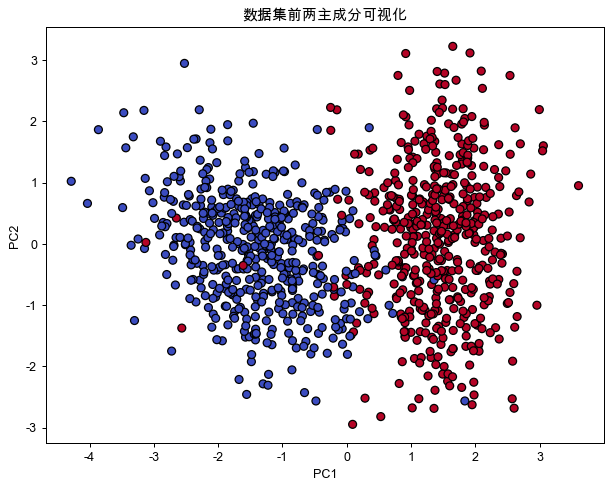

gamma=0.01, r=1, C=0.1, accuracy=0.9700
gamma=0.01, r=1, C=1, accuracy=0.9800
gamma=0.01, r=2, C=0.1, accuracy=0.9700
gamma=0.01, r=2, C=1, accuracy=0.9800
gamma=0.1, r=1, C=0.1, accuracy=0.9767
gamma=0.1, r=1, C=1, accuracy=0.9800
gamma=0.1, r=2, C=0.1, accuracy=0.9667
gamma=0.1, r=2, C=1, accuracy=0.9767

最佳模型参数:
gamma=scale, r=1, C=1

测试集准确率: 0.9800


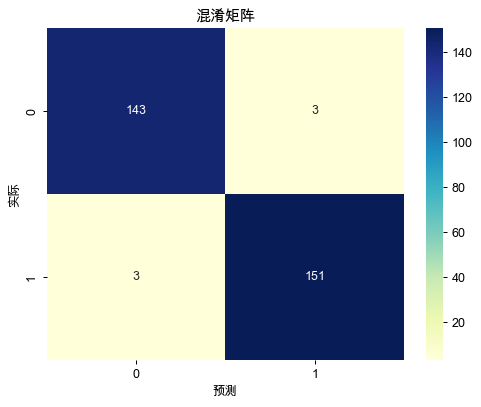

In [2]:
# ANOVA 核方法：基于 SVM 的非线性分类
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mpl_toolkits.mplot3d import Axes3D
from functools import partial

## 1.定义 ANOVA 核函数
def anova_kernel(X, Y, gamma=0.1, r=2):
    """
    自定义 ANOVA 核函数
    X: shape (n_samples_1, n_features)
    Y: shape (n_samples_2, n_features)
    返回: 核矩阵 shape (n_samples_1, n_samples_2)
    """
    K = np.zeros((X.shape[0], Y.shape[0]))
    for i in range(X.shape[1]):  # 遍历每一维特征
        Xi = X[:, i][:, np.newaxis]  # 取第 i 维度列向量
        Yi = Y[:, i][np.newaxis, :]  # 取第 i 维度行向量
        K += np.exp(-gamma * (Xi - Yi) ** 2) ** r
    return K

## 2.构造数据集
X, y = make_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=0,
                           n_clusters_per_class=1, class_sep=1.5, random_state=42)

# 可视化前两个主成分
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', s=40, edgecolor='k')
plt.title("数据集前两主成分可视化")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 3.划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4.使用 GridSearch + 自定义核函数优化模型
class CustomKernelSVC(SVC):
    def __init__(self, gamma=0.1, r=2, C=1.0):
        self.gamma = gamma
        self.r = r
        super().__init__(kernel=partial(anova_kernel, gamma=gamma, r=r), C=C)

    def kernel_function(self, X, Y):
        return anova_kernel(X, Y, gamma=self.gamma, r=self.r)


# 参数搜索范围
param_grid = {
    'gamma': [0.01, 0.1],
    'r': [1, 2],
    'C': [0.1, 1]
}

best_model = None
best_score = 0

for gamma in param_grid['gamma']:
    for r in param_grid['r']:
        for C in param_grid['C']:
            model = CustomKernelSVC(gamma=gamma, r=r, C=C)
            model.fit(X_train, y_train)
            score = model.score(X_test, y_test)
            print(f"gamma={gamma}, r={r}, C={C}, accuracy={score:.4f}")
            if score > best_score:
                best_score = score
                best_model = model

## 5.模型评估与结果分析
print("\n最佳模型参数:")
print(f"gamma={best_model.gamma}, r={best_model.r}, C={best_model.C}")

# 预测结果
y_pred = best_model.predict(X_test)

# 准确率
acc = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {acc:.4f}")

# 混淆矩阵
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu")
plt.title("混淆矩阵")
plt.xlabel("预测")
plt.ylabel("实际")
plt.show()


分类报告:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       146
           1       0.98      0.98      0.98       154

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



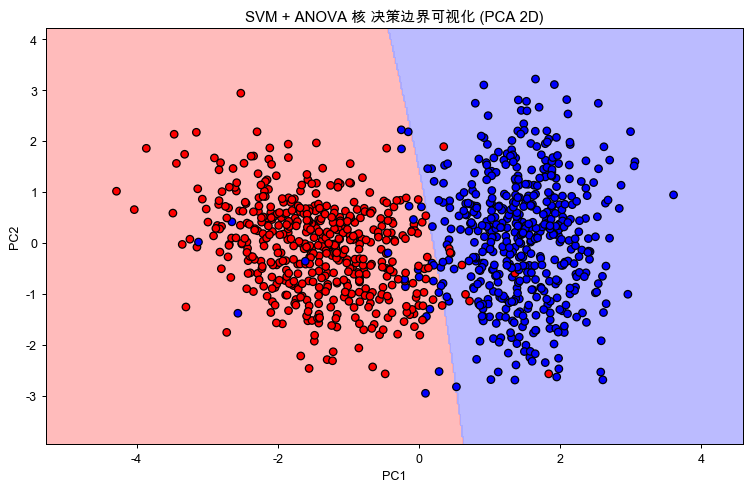

In [3]:
# 分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred))

## 6.可视化决策边界（PCA 降到 2D 后）
from matplotlib.colors import ListedColormap

h = .02  # 网格步长
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]

# 映射回原始特征空间
X_proj_back = pca.inverse_transform(grid_points)
y_grid_pred = best_model.predict(X_proj_back)
y_grid_pred = y_grid_pred.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, y_grid_pred, cmap=ListedColormap(["#FFAAAA", "#AAAAFF"]), alpha=0.8)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=ListedColormap(["#FF0000", "#0000FF"]), edgecolors='k')
plt.title("SVM + ANOVA 核 决策边界可视化 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**1. 自定义 ANOVA 核函数**

这一部分定义了 ANOVA 核函数：


$$
K(x, y) = \sum_{i=1}^{d} \left[ \exp(-\gamma(x_i - y_i)^2) \right]^r
$$


- 对每个特征维度单独计算；
- 用循环对所有维度累计；
- 支持任意样本集之间的核矩阵计算。

这是整套算法的核心。

**2. 构造数据集并 PCA 降维可视化**

- 使用 `make_classification` 构造一个具有 5 个特征的分类数据；
- 通过 PCA 降维到 2 维进行可视化展示；
- 可以观察样本是否有较明显的可分性。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

**3. 训练集与测试集划分**

标准的 70/30 分割，有助于后续模型评估的泛化能力测试。

**4. SVM 模型 + 自定义核 + 网格搜索优化**

- 使用继承方式包装 `SVC`，让其支持我们定义的 `anova_kernel`；
- 用 3 重 for 循环暴力搜索 gamma、r、C 三个超参数；
- 记录最佳模型和对应准确率。

这种方式虽然不如 `GridSearchCV` 自动化，但便于控制逻辑，尤其是自定义核。

**5. 性能评估**

- 打印最佳参数；
- 输出准确率；
- 绘制混淆矩阵热力图；
- 分类报告显示精确率、召回率、F1 值等核心指标。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

这些可以帮我们清晰理解模型是否偏斜、是否过拟合。

**6. 决策边界可视化（PCA 降到 2D）**

- 在 2D 平面上做网格点采样；
- 将网格点逆变换回原始特征空间；
- 对网格点分类预测，绘制决策边界；

![原文参考图，当前结果见代码输出](attachments/img_021.png)

通过这一步，能非常直观地看到 ANOVA 核 SVM 如何进行非线性划分。

**8. 后续优化建议**

如需进一步提升算法性能或应用于真实任务，大家可以考虑：

1. 使用 `KernelCenterer` 对核矩阵做中心化处理；
2. 用 `StratifiedKFold` 替代简单划分以增强稳定性；
3. 将数据标准化或归一化；
4. 将 `anova_kernel` 替换为多阶 ANOVA 核，考虑维度交互；
5. 用 `joblib` 并行加速网格搜索。

## 模型分析

### 使用 ANOVA 核的优缺点

**优点：**

1. **维度分解能力强**：ANOVA 核对每一维特征进行单独建模，避免特征之间互相干扰，有助于提升模型的可解释性，特别是在每一维的特征含义明确时（如医学特征、实验因子等）。
2. **更强的非线性建模能力（可调）**：参数 $r$ 提供了调节非线性强度的手段。相比 RBF 核只能通过 gamma 控制距离，ANOVA 核可以同时通过 gamma 与 $r$ 灵活建模复杂的非线性。
3. **不易过拟合高维交互**：因为它不考虑高阶特征交互项，所以在一些变量之间高度独立的任务中（如高维基因表达数据）可以有效避免过拟合。
4. **适合特征贡献独立的场景**：如果任务中各个特征维度是独立或独立解释的（如时间序列的不同时间点），ANOVA 核能够突出每一个变量的单独效应。

**缺点：**

1. **忽略变量之间的交互信息**：它假设每一维度的特征独立建模，这在特征之间存在显著联动（比如文本、图像、时间序列）的情况下是严重限制，可能导致信息损失。
2. **对参数敏感（gamma 和 r）**：参数调节复杂，不如线性核或 RBF 核直观，必须借助交叉验证等策略才能找到合适的 gamma 和 r，否则性能可能很差。
3. **无明确映射函数解释（不可显式展开）**：它的隐式映射空间较难解析，无法像多项式核那样明确列出映射特征，因此解释性和理论分析相对较弱。
4. **计算成本比线性核大**：每一维都要逐项计算指数函数，计算量和存储量随样本数和维度增长明显提升。

### 与其他核函数对比

| 核函数类型 | 特点简述 | 是否考虑特征交互 | 非线性能力 | 参数控制 | 适用情况 |
|-|-|-|-|-|-|
| **线性核** | 内积计算，等价线性模型 | 否 | 弱（线性） | 无 | 特征已线性分离、大量特征或稀疏特征 |
| **RBF 核** | 基于欧式距离的高斯函数，考虑所有维度合成的距离 | 是 | 强 | γ | 非线性边界、特征交互影响大的任务 |
| **多项式核** | 模拟多项式映射，如 $(x^T y + c)^d$ | 是 | 强（可调） | degree, c | 特征组合重要时，如手写字识别等 |
| **ANOVA 核** | 按特征维度分解的核函数，忽略交互项 | 否 | 中到强（可调） | γ, r | 每个特征重要且彼此独立、少交互的场景 |

### 何时优选 ANOVA 核，何时选择其他核？

**优选 ANOVA 核的场景：**

- **特征之间独立、解释意义明确**：如问卷调查的每个问题，医学变量的多个生理指标，或实验中的不同因子处理。
- **维度不太高，且每维特征重要性均高**：适合中小维度问题，每个维度都可能提供重要信息。
- **任务中变量交互性弱或不可解释**：如某些时间序列点预测、简单环境因子控制任务。
- **你想要更强的非线性建模能力**，但不希望模型在特征间产生复杂联动（容易过拟合）时。

**建议选择其他核的场景：**

- **特征间高度相关（如图像、自然语言）**：RBF 或多项式核更合适，因为它们能建模复杂交互。
- **数据线性可分或特征数量非常高（如稀疏文本数据）**：线性核训练速度快且泛化能力好。
- **存在高阶组合关系**：如多项式核擅长挖掘组合特征。
- **计算效率是主要瓶颈**：ANOVA 核比 RBF 核更慢，如实时预测任务可优先考虑线性或简化核。

## 总结

ANOVA 核方法通过对每个特征维度进行独立的非线性建模，在特征之间交互较弱、单个变量具有显著影响的任务中表现出色，是核方法家族中兼具灵活性与可解释性的一类选择，但其有效性依赖于对数据结构的深刻理解与参数的精心调优。